# ChromGraphFM — Exploratory Data Analysis (data only)

This notebook walks through **every data artefact** the project builds, from the raw
downloads to the exact tensors a training batch hands to the model.

* It is **read-only on `data/`** — nothing here writes to (or modifies) the raw or
  processed dataset, so it is safe to run while training is in progress.
* It contains **no model code and no training loop** — no losses, no forward
  passes. Graph construction is shown purely as *data*, because it defines what
  the model sees.

Pipeline reference: `scripts/build_data.py` (Phase 1), `chromgraph/data.py`,
`chromgraph/graph.py` (Phase 2). Config lives in `configs/base.yaml`.

## 0. Setup

Two plotting libraries (`matplotlib`, `seaborn`) are missing from the Jupyter
kernel. They are installed here with `%pip`, once. Everything else (numpy,
pandas, scipy, cooler, pyfaidx, the `chromgraph` package) is already present.

In [1]:
%pip install -q matplotlib seaborn


[notice] A new release of pip is available: 24.1.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
REPO = cwd if (cwd / "chromgraph").exists() else cwd.parent
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from chromgraph.config import load_config, data_dir, results_dir
from chromgraph.data import load_manifest, load_chromosome
from chromgraph.graph import build_sample, sample_starts, ARMS

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="muted")
except ImportError:
    plt.style.use("seaborn-v0_8-whitegrid")

import cooler

np.random.seed(0)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

print("REPO root :", REPO)
print("data dir  :", data_dir())
print("results   :", results_dir())

REPO root : /home/jupyter-238w1a5447/3D-Chromatin-Aware-Genomic-FM
data dir  : /home/jupyter-238w1a5447/3D-Chromatin-Aware-Genomic-FM/data
results   : /home/jupyter-238w1a5447/3D-Chromatin-Aware-Genomic-FM/results


## 1. What this dataset is — manifest and config

`data/manifest.json` is the *only* data artefact git carries. hg38 is 3.1 GB and
one `.mcool` is 5–30 GB, so the raw files are rebuilt from this manifest on each
machine. The config cells define how that raw data becomes training shards.

In [3]:
man = load_manifest()
print("assembly      :", man["assembly"]["name"], "|", man["assembly"].get("note", ""))
print()
for cl, info in man["cell_lines"].items():
    mc = info["mcool"]
    print(f"  {cl}")
    print(f"    accession : {mc.get('accession')}")
    print(f"    md5 known : {'yes' if mc.get('md5') else 'no'}  (mirror: {'yes' if 'mirror' in mc else 'no'})")
    print(f"    url       : {mc.get('url')}")

assembly      : hg38 | UCSC naming ('chr1'), which matches 4DN's mcool bin table.

  GM12878
    accession : 4DNFIXP4QG5B
    md5 known : yes  (mirror: yes)
    url       : https://data.4dnucleome.org/files-processed/4DNFIXP4QG5B/@@download/4DNFIXP4QG5B.mcool
  K562
    accession : 4DNFI18UHVRO
    md5 known : no  (mirror: no)
    url       : https://data.4dnucleome.org/files-processed/4DNFI18UHVRO/@@download/4DNFI18UHVRO.mcool
  IMR90
    accession : 4DNFIJTOIGOI
    md5 known : no  (mirror: no)
    url       : https://data.4dnucleome.org/files-processed/4DNFIJTOIGOI/@@download/4DNFIJTOIGOI.mcool


In [4]:
for line in man.get("_comment", []):
    print("*", line)

* The only data artefact git carries. Everything under data/raw and
* data/processed is rebuilt from here by scripts/build_data.py, because
* hg38 is 3.1 GB and a single .mcool is 5-30 GB.
* 
* Accessions were verified live against the 4DN API in an earlier phase of
* this project (commit dc7e195) rather than guessed. Download URLs use the
* portal's @@download endpoint, which redirects to S3 -- more durable than
* pinning the S3 object UUID.
* 
* GM12878's mcool md5 was computed from the fully downloaded file on the
* L40S box and cross-checked against S3's own multipart ETag
* (55f2a41867b297a031091266680da249-3268, 8 MiB parts), so it attests to the
* bytes S3 stores, not merely to one local copy. K562 and IMR90 have no md5
* because those files have not been downloaded yet -- add each one only from
* a file that has actually been fetched and checked, never from a guess.
* 
* Depth caveat: GM12878's map is built from 72 experiments. K562 has 6 and
* IMR90 has 7, so both companion ma

In [5]:
cfg = load_config()
d, m, t = cfg.data, cfg.model, cfg.train
print("bin size        :", d.bin_size, "bp")
print("nodes / sample  :", d.nodes_per_sample, f"  (context = {d.context_bp/1000:.0f} kb)")
print("distal edges    : top-", d.top_k_edges, " per node, separation >=", d.min_separation, "bins")
print("local chain     : +/-", d.local_radius, "bins, always present")
print("held-out edges  :", d.held_out_edge_frac, "of ALL distal edges (targets, never conditioned on)")
print("cell lines      :", d.cell_lines)
print("splits          : train", len(d.chroms_train), "| val", len(d.chroms_val), "| test", len(d.chroms_test))
print("model           : d=%d  blocks=%d  heads=%d  | train.steps=%d  arm=%s" %
      (m.d_model, m.block_layers, m.n_heads, t.steps, t.arm))

bin size        : 5000 bp
nodes / sample  : 128   (context = 640 kb)
distal edges    : top- 16  per node, separation >= 5 bins
local chain     : +/- 3 bins, always present
held-out edges  : 0.15 of ALL distal edges (targets, never conditioned on)
cell lines      : ['GM12878']
splits          : train 17 | val 2 | test 3
model           : d=256  blocks=4  heads=8  | train.steps=20000  arm=full


## 2. Raw downloads on disk

Everything under `data/raw` is downloaded by `build_data.py` (Phase 1):

* `hg38.fa` — the reference genome (UCSC, 3.1 GB). Indexed by pyfaidx.
* `<accession>.mcool` — GM12878 Hi-C contact matrix from 4DN (5 kb resolution).

Sizes below are read-only snapshot; the notebook never touches these files.

In [6]:
raw = data_dir() / "raw"
print("data/raw:")
tot = 0.0
for f in sorted(raw.iterdir()):
    mb = f.stat().st_size / 1e6
    tot += mb
    print(f"  {f.name:<22} {mb:9.1f} MB")
print(f"  {'TOTAL':<22} {tot:9.1f} MB")

proc = data_dir() / "processed"
print("\ndata/processed/  (per cell line, per chromosome @ 5 kb)")
for cl in sorted(p.name for p in proc.iterdir() if p.is_dir()):
    csum = 0.0
    print(f"  cell line: {cl}")
    for f in sorted(proc.joinpath(cl).iterdir()):
        if f.is_dir():
            mb = sum(q.stat().st_size for q in f.rglob("*") if q.is_file()) / 1e6
            csum += mb
            print(f"    {f.name:<14} {mb:9.1f} MB")
    print(f"    {'TOTAL':<14} {csum:9.1f} MB")

data/raw:
  4DNFIXP4QG5B.mcool       27408.9 MB
  hg38.fa                   3273.5 MB
  hg38.fa.fai                  0.0 MB
  hg38.fa.gz                 983.7 MB
  TOTAL                    31666.0 MB

data/processed/  (per cell line, per chromosome @ 5 kb)
  cell line: GM12878
    chr10_5000         225.4 MB
    chr11_5000         228.1 MB
    chr12_5000         225.3 MB
    chr13_5000         179.9 MB
    chr14_5000         168.3 MB
    chr15_5000         156.5 MB
    chr16_5000         142.1 MB
    chr17_5000         137.3 MB
    chr18_5000         131.8 MB
    chr19_5000          98.0 MB
    chr1_5000          404.7 MB
    chr20_5000         108.0 MB
    chr21_5000          69.1 MB
    chr22_5000          74.6 MB
    chr2_5000          406.0 MB
    chr3_5000          335.5 MB
    chr4_5000          317.1 MB
    chr5_5000          303.5 MB
    chr6_5000          288.3 MB
    chr7_5000          264.8 MB
    chr8_5000          242.9 MB
    chr9_5000          216.1 MB
    TOTAL         

## 3. Raw genome — hg38

Chromosome lengths come straight from the pyfaidx index (`hg38.fa.fai`). The
colour coding marks how each chromosome is used: training, validation, test,
or not built at all.

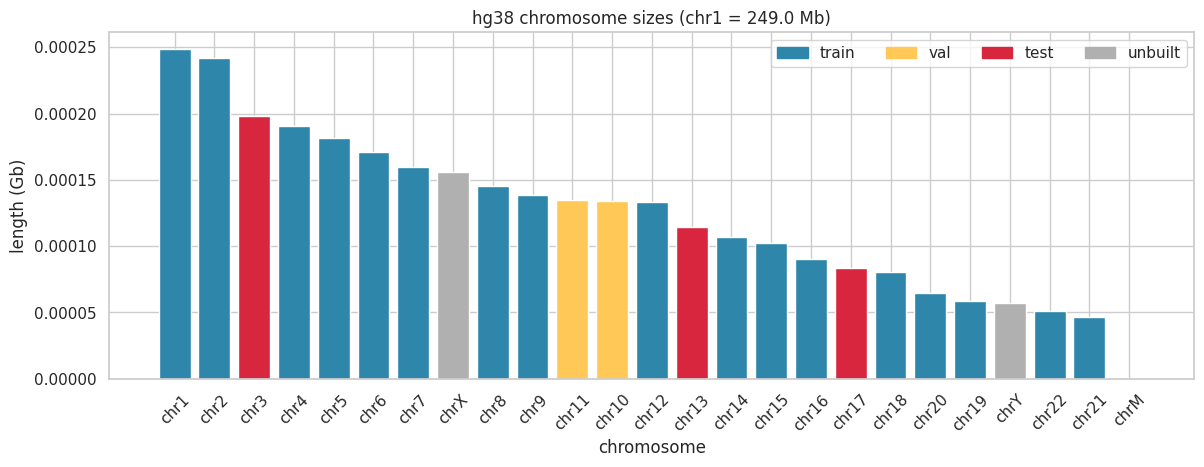

In [7]:
fai = pd.read_csv(raw / "hg38.fa.fai", sep="\t", header=None,
                  names=["chrom", "length", "offset", "linebases", "linewidth"])
std = fai[fai["chrom"].str.match(r"^chr(\d+|X|Y|M)$", na=False)].copy()
std["Mb"] = std["length"] / 1e6
std = std.sort_values("length", ascending=False)

split_of = {}
for sp, chroms in (("train", cfg.data.chroms_train), ("val", cfg.data.chroms_val),
                   ("test", cfg.data.chroms_test)):
    for c in chroms:
        split_of[c] = sp
_colors = {"train": "#2e86ab", "val": "#ffc857", "test": "#d7263d", "unbuilt": "#b0b0b0"}

plt.figure(figsize=(14, 4.5))
bars = plt.bar(std["chrom"], std["Mb"] / 1e6, color=[_colors.get(split_of.get(c, "unbuilt"), "#b0b0b0") for c in std["chrom"]])
plt.ylabel("length (Gb)")
plt.xlabel("chromosome")
plt.title(f"hg38 chromosome sizes ({std['chrom'].iloc[0]} = {std['Mb'].iloc[0]:.1f} Mb)")
plt.xticks(rotation=45)
leg = [plt.Rectangle((0, 0), 1, 1, color=c) for c in _colors.values()]
plt.legend(leg, _colors.keys(), ncol=4, loc="upper right")
plt.show()

### 3.1 Base composition of the built chromosomes

Read from the processed `seq.npy` shards (uint8 codes: A=0, C=1, G=2, T=3,
N=4). Two sanity checks every genomics model should eyeball:

* **GC fraction ≈ 0.40–0.42** — the human genome is ~41% GC.
* **N fraction ≈ 0** on clean chromosomes; large values flag assembly gaps
  (e.g. centromeric regions of pre-Q-arms or acrocentric chromosomes).

In [8]:
rows = []
for d_dir in sorted((data_dir() / "processed" / "GM12878").glob("chr*_5000")):
    chrom = d_dir.name.split("_")[0]
    seq = np.load(d_dir / "seq.npy", mmap_mode="r")
    counts = np.zeros(5, np.int64)
    for s in range(0, seq.shape[0], 2000):          # chunked -> small peak memory
        counts += np.bincount(np.asarray(seq[s:s + 2000]).ravel(), minlength=5)[:5]
    frac = counts / counts.sum()
    gc = (counts[1] + counts[2]) / max(1, counts[:4].sum())
    rows.append({"chrom": chrom, "A": frac[0], "C": frac[1], "G": frac[2], "T": frac[3],
                 "N": frac[4], "GC": gc})
bases_df = pd.DataFrame(rows)
bases_df

,chrom,A,C,G,T,N,GC
0,chr10,0.290553,0.206573,0.207175,0.291686,0.004014,0.415415
1,chr11,0.290819,0.206553,0.207135,0.291376,0.004118,0.415398
2,chr12,0.295394,0.203277,0.203952,0.296310,0.001067,0.407664
3,chr13,0.262734,0.164729,0.165554,0.263741,0.143242,0.385503
4,chr14,0.249179,0.172112,0.173376,0.251408,0.153925,0.408342
5,chr15,0.240293,0.174057,0.174772,0.240735,0.170142,0.420348
6,chr16,0.249705,0.201159,0.202568,0.252102,0.094466,0.445844
7,chr17,0.271913,0.224885,0.226417,0.272703,0.004081,0.453152
8,chr18,0.299231,0.196510,0.199834,0.300875,0.003551,0.397756
9,chr19,0.258313,0.238052,0.239869,0.260709,0.003058,0.479387


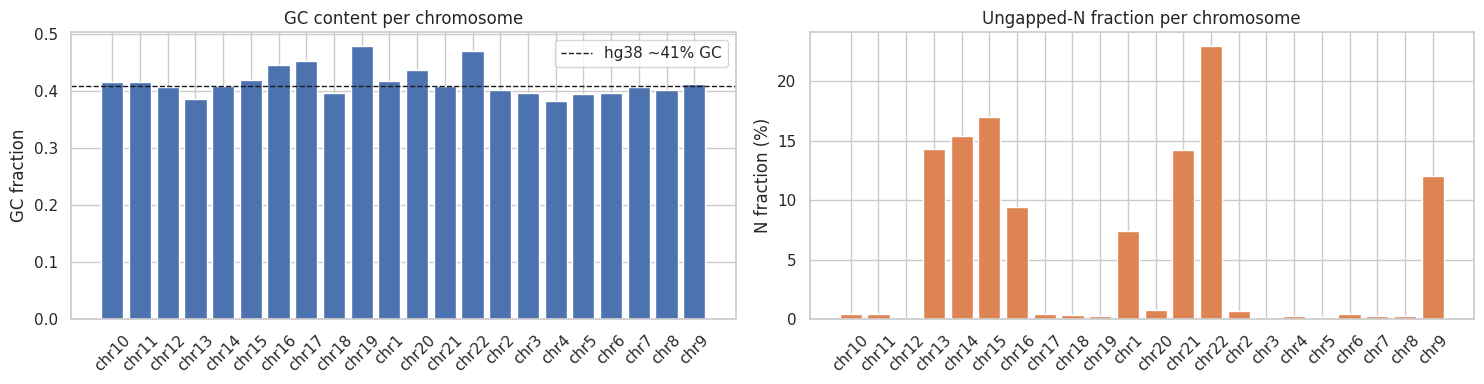

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].bar(bases_df["chrom"], bases_df["GC"], color="#4c72b0")
ax[0].axhline(0.41, color="k", ls="--", lw=1, label="hg38 ~41% GC")
ax[0].set_xticks(range(len(bases_df))); ax[0].set_xticklabels(bases_df["chrom"], rotation=45)
ax[0].set_ylabel("GC fraction"); ax[0].set_title("GC content per chromosome"); ax[0].legend()

ax[1].bar(bases_df["chrom"], bases_df["N"] * 100, color="#dd8452")
ax[1].set_xticks(range(len(bases_df))); ax[1].set_xticklabels(bases_df["chrom"], rotation=45)
ax[1].set_ylabel("N fraction (%)"); ax[1].set_title("Ungapped-N fraction per chromosome")
plt.tight_layout(); plt.show()

## 4. Raw Hi-C — the `.mcool`

Opened with `cooler` exactly the way `chromgraph/data.py` does
(`...::resolutions/5000`). The map is ICE-balanced; filtered bins carry NaN.

In [10]:
mcool_path = raw / f"{man['cell_lines']['GM12878']['mcool']['accession']}.mcool"
uri = f"{mcool_path}::resolutions/{cfg.data.bin_size}"
clr = cooler.Cooler(uri)
print("file      :", mcool_path.name)
print("resolution:", cfg.data.bin_size, "bp")
print("chroms    :", len(clr.chromnames), "| total length", clr.chromsizes.sum() / 1e6, "Mb")
for chrom in ["chr1", "chr20", "chr21"]:
    lo, hi = clr.extent(chrom)
    print(f"  {chrom}: {clr.chromsizes[chrom]/1e6:7.1f} Mb -> {hi-lo} bins")

file      : 4DNFIXP4QG5B.mcool
resolution: 5000 bp
chroms    : 24 | total length 3088.269832 Mb
  chr1:   249.0 Mb -> 49792 bins
  chr20:    64.4 Mb -> 12889 bins
  chr21:    46.7 Mb -> 9342 bins


In [11]:
pix = pd.DataFrame(clr.matrix(balance=True, as_pixels=True).fetch("chr20"))
pix.columns = ["bin1", "bin2", "count", "balanced"][:pix.shape[1]]
pix = pix[(pix["bin2"] - pix["bin1"] <= 200)]
print(pix.head(6))
print("...")
print("pixels (band <= 1 Mb):", len(pix))
print("nonzero              :", int((pix["balanced"] > 0).sum()))
print("NaN (ICE-filtered)   :", int(pix["balanced"].isna().sum()))

     bin1    bin2  count  balanced
0  542627  542627    727  0.455028
1  542627  542628     57  0.017190
2  542627  542629      9  0.002155
3  542627  542630     10  0.001836
4  542627  542631      6  0.001330
5  542627  542632      4  0.001333
...
pixels (band <= 1 Mb): 2305721
nonzero              : 2281650
NaN (ICE-filtered)   : 24071


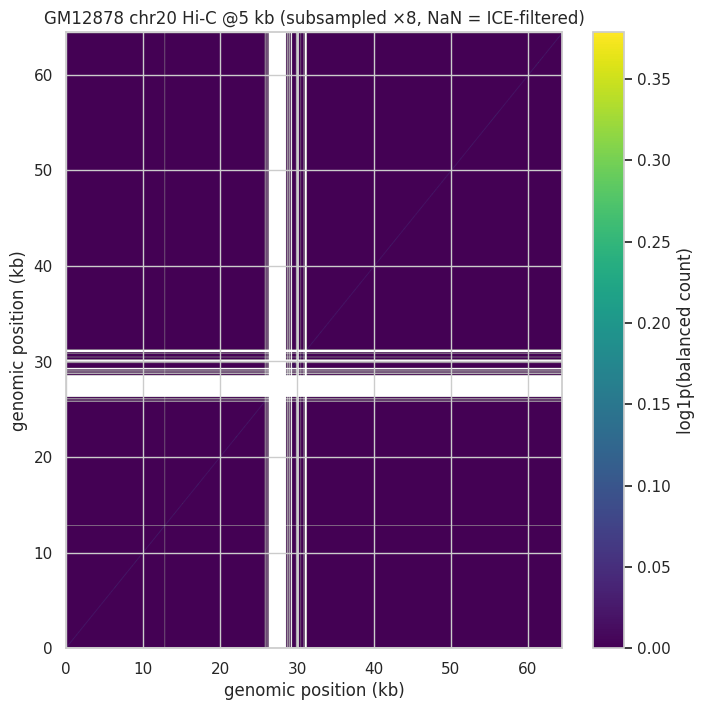

In [12]:
chrom = load_chromosome(data_dir(), "GM12878", "chr20", cfg.data.bin_size)
base_len = chrom["seq"].shape[0]

M = clr.matrix(balance=True).fetch("chr20")
if not isinstance(M, np.ndarray):
    M = M.toarray()
step = 8
thin = np.ma.masked_invalid(np.asarray(M[::step, ::step], dtype=np.float64))

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(np.log1p(thin), cmap="viridis", origin="lower", aspect="auto",
               extent=[0, base_len * 5e-3, 0, base_len * 5e-3])
plt.colorbar(im, ax=ax, label="log1p(balanced count)")
ax.set_xlabel("genomic position (kb)"); ax.set_ylabel("genomic position (kb)")
ax.set_title("GM12878 chr20 Hi-C @5 kb (subsampled ×8, NaN = ICE-filtered)")
plt.show()

## 5. The processed shards — what training actually reads

`build_data.py` writes, per (cell line, chromosome):

| file        | contents |
|-------------|----------|
| `bins.npz`  | per-bin N fraction, contact coverage, `usable` mask |
| `pixels.npz`| sparse upper-triangle contacts: `row`, `col`, `raw` (balanced), `oe`, `strength`, `expected` (P(s) curve) |
| `seq.npy`   | `(n_bins, 5000)` uint8 DNA, one row per bin |
| `qc.json`   | everything a reader needs to trust the shards (+ md5 checksums) |

Note the load only touches files under `data/processed/GM12878/chr20_5000`.

In [13]:
chrom = load_chromosome(data_dir(), "GM12878", "chr20", cfg.data.bin_size)
print("chrom keys:", sorted(chrom.keys()))
print("\nqc keys   :", sorted(chrom["qc"].keys()))
print()
print("shapes:")
print("  seq       ", chrom["seq"].shape, chrom["seq"].dtype, "(mmap, not fully loaded)")
print("  row/col   ", chrom["row"].shape, chrom["row"].dtype)
print("  oe        ", chrom["oe"].shape, chrom["oe"].dtype)
print("  strength  ", chrom["strength"].shape, chrom["strength"].dtype)
print("  usable    ", chrom["usable"].shape, chrom["usable"].dtype)
print("  n_frac    ", chrom["n_frac"].shape, chrom["n_frac"].dtype)
print("  coverage  ", chrom["coverage"].shape, chrom["coverage"].dtype)

chrom keys: ['col', 'coverage', 'dir', 'n_frac', 'oe', 'qc', 'row', 'seq', 'strength', 'usable']

qc keys   : ['bin_size', 'cell_line', 'checksums', 'chrom', 'expected_by_separation', 'frac_usable', 'max_separation_bins', 'n_bins', 'n_frac_mean', 'n_frac_over_threshold', 'n_pixels', 'n_usable_bins', 'ps_slope_10kb_1mb', 'spearman_oe_vs_separation', 'spearman_oe_vs_separation_with_zeros', 'spearman_separation_range_bins', 'strength_max', 'strength_min']

shapes:
  seq        (12889, 5000) uint8 (mmap, not fully loaded)
  row/col    (3982395,) int32
  oe         (3982395,) float32
  strength   (3982395,) float32
  usable     (12889,) bool
  n_frac     (12889,) float32
  coverage   (12889,) float32


In [14]:
code2base = np.array(list("ACGTN"), dtype="<U1")
good = int(np.flatnonzero(chrom["n_frac"] < 0.01)[0])   # first bin clear of assembly gaps
print(f"300 bases of bin {good} (5 kb window, N-frac {chrom['n_frac'][good]:.3f}):")
print("".join(code2base[np.asarray(chrom["seq"][good])[:300]]))
print()
print("(bin 0 is a telomere gap — all N — which is exactly why the N-fraction")
print(" threshold and the usable mask exist before any graph is built.)")

300 bases of bin 14 (5 kb window, N-frac 0.000):
TAAAATTGACTTCCAGATCCACTAAGATGAAATAGGGCATTTTTCCTAAGTCCTCCCTTTTACCTCTCAAAAATCCTGAACATAATACAATAAACAAGCATAGGAATACTCTGAAATGTGGAAAGAATACAGTGGACTACTTATAGTCCTCAAGACTTAAGGAACTCCATGGGTCTCAGTTCTCTGGGTTTCCTTATTGTCTTGCATATATCCAGGACAGGTGCTACAAATATTCCAATGCAGAACAGAAAAAAGCATCCTTCTGTGTCTGTTACCCCATGCAACAATATCAAAAGTTGA

(bin 0 is a telomere gap — all N — which is exactly why the N-fraction
 threshold and the usable mask exist before any graph is built.)


### 5.1 QC summary across every built chromosome

The runbook's stop-gates, per chromosome: `frac_usable` (~0.9 expected),
`ps_slope_10kb_1mb` (−0.75…−1.2 expected for mammalian Hi-C) and
`spearman_oe_vs_separation` (~0 expected if detrending worked).

In [15]:
qc_rows = []
for d_dir in sorted((data_dir() / "processed" / "GM12878").glob("chr*_5000")):
    q = json.loads((d_dir / "qc.json").read_text())
    qc_rows.append({
        "chrom": q["chrom"],
        "bins": q["n_bins"],
        "pixels": q["n_pixels"],
        "frac_usable": round(q["frac_usable"], 3),
        "N_frac_mean": round(q["n_frac_mean"], 3),
        "ps_slope": round(q["ps_slope_10kb_1mb"], 3),
        "spearman": round(q["spearman_oe_vs_separation"], 3),
        "spear_w0": round(q["spearman_oe_vs_separation_with_zeros"], 3),
    })
qc_df = pd.DataFrame(qc_rows)
qc_df

,chrom,bins,pixels,frac_usable,N_frac_mean,ps_slope,spearman,spear_w0
0,chr10,26760,8359414,0.967,0.004,-0.893,-0.051,-0.079
1,chr11,27018,8490239,0.958,0.004,-0.922,-0.049,-0.078
2,chr12,26656,8391779,0.973,0.001,-0.915,-0.055,-0.086
3,chr13,22873,5959856,0.834,0.143,-0.865,-0.027,-0.073
4,chr14,21409,5577601,0.812,0.154,-0.913,-0.050,-0.082
5,chr15,20399,4978708,0.762,0.170,-0.939,-0.057,-0.079
6,chr16,18068,4730158,0.833,0.094,-0.926,-0.038,-0.061
7,chr17,16652,4937361,0.926,0.004,-1.003,-0.062,-0.079
8,chr18,16075,4689319,0.927,0.004,-0.887,-0.037,-0.072
9,chr19,11724,3601470,0.935,0.003,-0.980,-0.059,-0.074


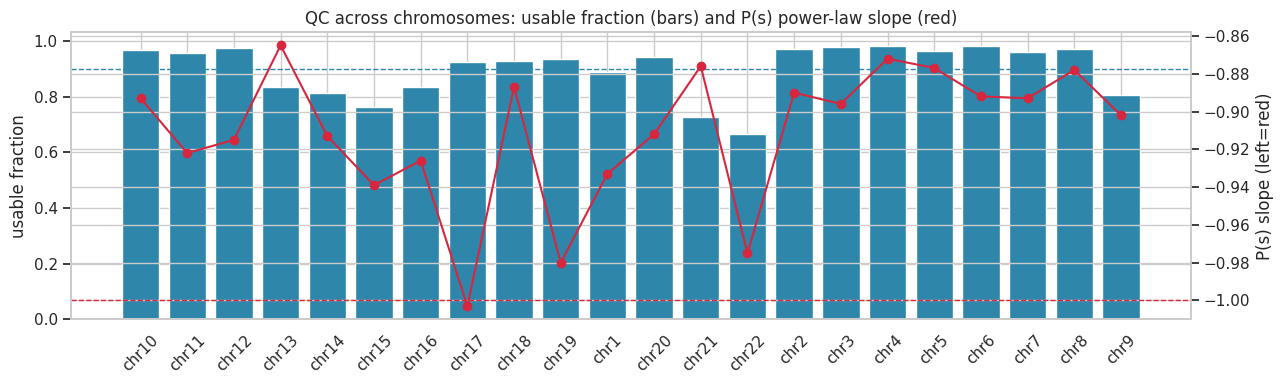

In [16]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(qc_df["chrom"], qc_df["frac_usable"], color="#2e86ab", label="frac_usable")
ax2 = ax.twinx()
ax2.plot(qc_df["chrom"], qc_df["ps_slope"], "o-", color="#d7263d", label="ps_slope (log-log)")
ax.axhline(0.9, color="#2e86ab", ls="--", lw=1)
ax2.axhline(-1.0, color="#d7263d", ls="--", lw=1)
ax.set_xticks(range(len(qc_df))); ax.set_xticklabels(qc_df["chrom"], rotation=45)
ax.set_ylabel("usable fraction"); ax2.set_ylabel("P(s) slope (left=red)")
lns, lbs = ax.get_legend_handles_labels() + ax2.get_legend_handles_labels(), []
plt.title("QC across chromosomes: usable fraction (bars) and P(s) power-law slope (red)")
plt.tight_layout(); plt.show()

## 6. The science checks on a chromosome

These are the *load-bearing* properties of the data — the things that have to be
right or every downstream number is meaningless:

1. **P(s) decays as a power law** — near things touch more. Expected slope ≈ −0.9.
2. **O/E ≈ 1 everywhere** after detrending — the distance effect is removed, so
   a top-k over `strength` selects *structure*, not proximity.
3. **Spearman(O/E, separation) ≈ 0** — no residual distance trend.

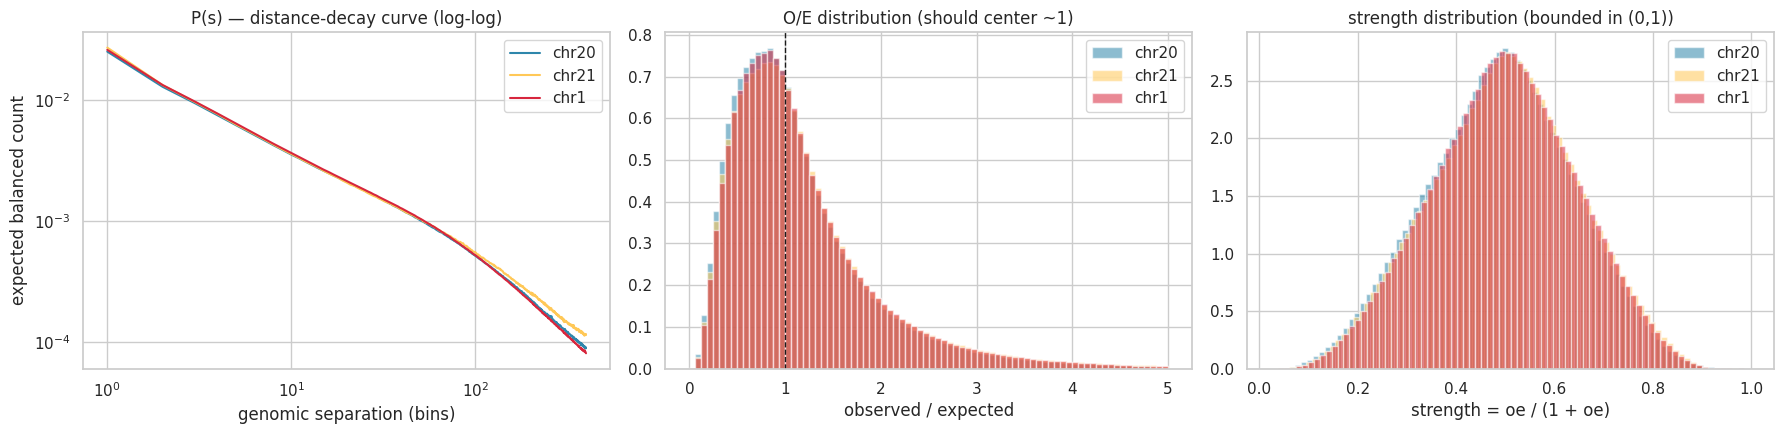

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))

colors = {"chr20": "#2e86ab", "chr21": "#ffc857", "chr1": "#d7263d"}
for cd, c in colors.items():
    ch = load_chromosome(data_dir(), "GM12878", cd, cfg.data.bin_size)
    pix = np.load(ch["dir"] / "pixels.npz")
    exp = pix["expected"]
    s = np.arange(1, len(exp))
    axes[0].loglog(s, exp[1:], color=c, label=cd)
axes[0].set_xlabel("genomic separation (bins)"); axes[0].set_ylabel("expected balanced count")
axes[0].set_title("P(s) — distance-decay curve (log-log)"); axes[0].legend()

for cd, c in colors.items():
    ch = load_chromosome(data_dir(), "GM12878", cd, cfg.data.bin_size)
    rng = np.random.default_rng(0)
    idx = rng.choice(len(ch["oe"]), size=min(1_500_000, len(ch["oe"])), replace=False)
    axes[1].hist(ch["oe"][idx], bins=80, range=(0, 5), color=c, alpha=0.55, density=True, label=cd)
axes[1].axvline(1.0, color="k", ls="--", lw=1)
axes[1].set_xlabel("observed / expected"); axes[1].set_title("O/E distribution (should center ~1)"); axes[1].legend()

for cd, c in colors.items():
    ch = load_chromosome(data_dir(), "GM12878", cd, cfg.data.bin_size)
    rng = np.random.default_rng(0)
    idx = rng.choice(len(ch["strength"]), size=min(1_500_000, len(ch["strength"])), replace=False)
    axes[2].hist(ch["strength"][idx], bins=80, color=c, alpha=0.55, density=True, label=cd)
axes[2].set_xlabel("strength = oe / (1 + oe)"); axes[2].set_title("strength distribution (bounded in (0,1))"); axes[2].legend()

plt.tight_layout(); plt.show()

In [18]:
print("Per-chromosome QC lines (cut straight from qc.json):")
for cd in ["chr20", "chr21", "chr1"]:
    ch = load_chromosome(data_dir(), "GM12878", cd, cfg.data.bin_size)
    q = ch["qc"]
    print(f"  {cd}: slope={q['ps_slope_10kb_1mb']:+.3f}  spearman={q['spearman_oe_vs_separation']:.3f}  "
          f"frac_usable={q['frac_usable']:.3f}")

Per-chromosome QC lines (cut straight from qc.json):


  chr20: slope=-0.912  spearman=-0.055  frac_usable=0.941
  chr21: slope=-0.876  spearman=-0.025  frac_usable=0.725


  chr1: slope=-0.933  spearman=-0.047  frac_usable=0.888


### 6.1 Coverage and usable bins

`usable = (N-fraction ≤ 50%) & (contact coverage > 0)`. This mask decides which
bins participate in edges and which windows can be sampled (min 60% usable).

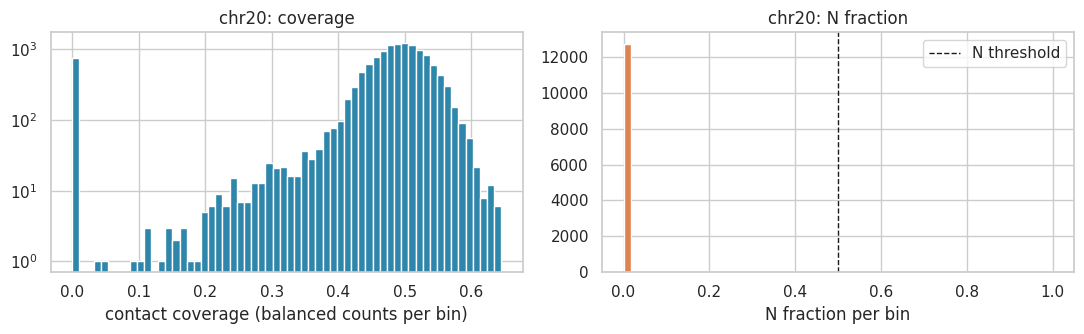

  chr20: 94.1% of bins usable


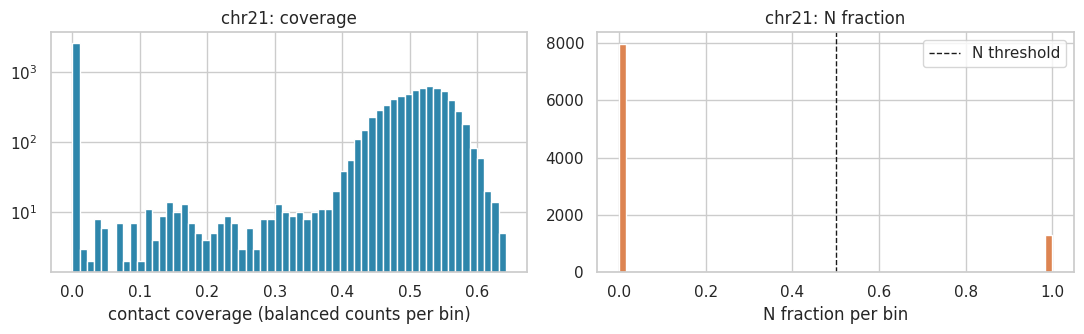

  chr21: 72.5% of bins usable


In [19]:
for cd in ["chr20", "chr21"]:
    ch = load_chromosome(data_dir(), "GM12878", cd, cfg.data.bin_size)
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].hist(ch["coverage"], bins=60, log=True, color="#2e86ab")
    axes[0].set_xlabel("contact coverage (balanced counts per bin)"); axes[0].set_title(f"{cd}: coverage")
    axes[1].hist(ch["n_frac"], bins=60, color="#dd8452")
    axes[1].axvline(cfg.data.max_n_frac, color="k", ls="--", lw=1, label="N threshold")
    axes[1].legend(); axes[1].set_xlabel("N fraction per bin"); axes[1].set_title(f"{cd}: N fraction")
    plt.tight_layout(); plt.show()
    print(f"  {cd}: {ch['usable'].mean()*100:.1f}% of bins usable")

## 7. The graph a model conditions on (data only)

`build_sample` (Phase 2) slices a contiguous run of `nodes_per_sample=128` bins
(= 640 kb) and builds three edge sets from the detrended contact map:

* **local edges** — the sequential chain (adjacent, ±3 bins), always present;
* **distal edges** — each node's top-16 strongest partners ≥ 5 bins away —
  selected on *detrended* strength so the model cannot solve the task by
  measuring distance;
* **held-out targets** — 15% of distal edges, guaranteed disjoint from the
  conditioning graph (the contact head must predict them without having seen
  them).

In [20]:
ch = load_chromosome(data_dir(), "GM12878", "chr20", cfg.data.bin_size)
smp = build_sample(cfg, ch, "GM12878", "chr20", start_bin=4000, arm="full")

print("nodes            :", smp.n_nodes, "x", cfg.data.bin_size, "bp =", smp.n_nodes * cfg.data.bin_size / 1000, "kb")
print("seq shape        :", smp.seq.shape, smp.seq.dtype)
print("conditioning edges:", smp.edge_index.shape[1],
      " (local:", int(smp.edge_is_local.sum()), ", distal:", int((~smp.edge_is_local).sum()), ")")
print("held-out targets :", smp.tgt_index.shape[1])
print("strength range   : %.3f .. %.3f" % (smp.edge_strength.min(), smp.edge_strength.max()))
print("sep (bins)       : min %d, median %d, max %d" % (smp.edge_sep.min(), np.median(smp.edge_sep), smp.edge_sep.max()))
print("node Hi-C feats  :", smp.node_hic_feat.shape, "(sum, max, count per node — used by late-fusion arm)")

nodes            : 128 x 5000 bp = 640.0 kb
seq shape        : (128, 5000) uint8
conditioning edges: 1797  (local: 378 , distal: 1419 )
held-out targets : 231
strength range   : 0.358 .. 0.884
sep (bins)       : min 1, median 60, max 127
node Hi-C feats  : (128, 3) (sum, max, count per node — used by late-fusion arm)


In [21]:
# The invariant the whole contact objective rests on:
cond = {(int(a), int(b)) for a, b in smp.edge_index.T}
tgt = {(int(a), int(b)) for a, b in smp.tgt_index.T}
print("target edges inside conditioning edges:", bool(cond & tgt), "(must be False)")

target edges inside conditioning edges: False (must be False)


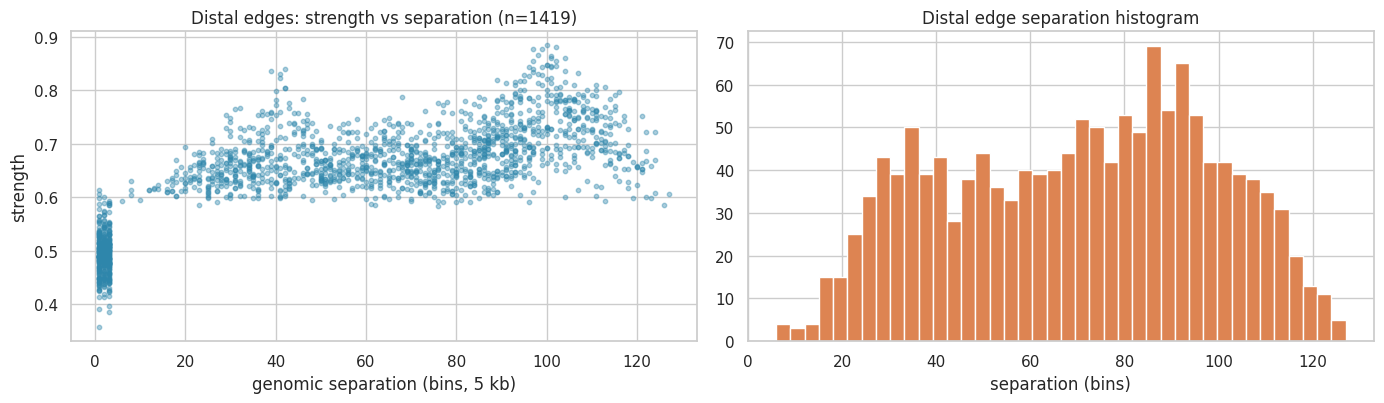

In [22]:
distal = ~smp.edge_is_local
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].scatter(smp.edge_sep, smp.edge_strength, s=10, alpha=0.4, color="#2e86ab")
axes[0].set_xlabel("genomic separation (bins, 5 kb)"); axes[0].set_ylabel("strength")
axes[0].set_title(f"Distal edges: strength vs separation (n={int(distal.sum())})")
axes[1].hist(smp.edge_sep[distal], bins=40, color="#dd8452")
axes[1].set_xlabel("separation (bins)"); axes[1].set_title("Distal edge separation histogram")
plt.tight_layout(); plt.show()

### 7.1 Visualising the Hi-C graphs

Four views of the same sparse contact graph the model conditions on:
the adjacency matrix, the edges as a circular chord graph, the strongest distal
contacts laid over genomic position (the classic Hi-C "arc" view), and the
degree / density statistics that decide how expressive each node is.

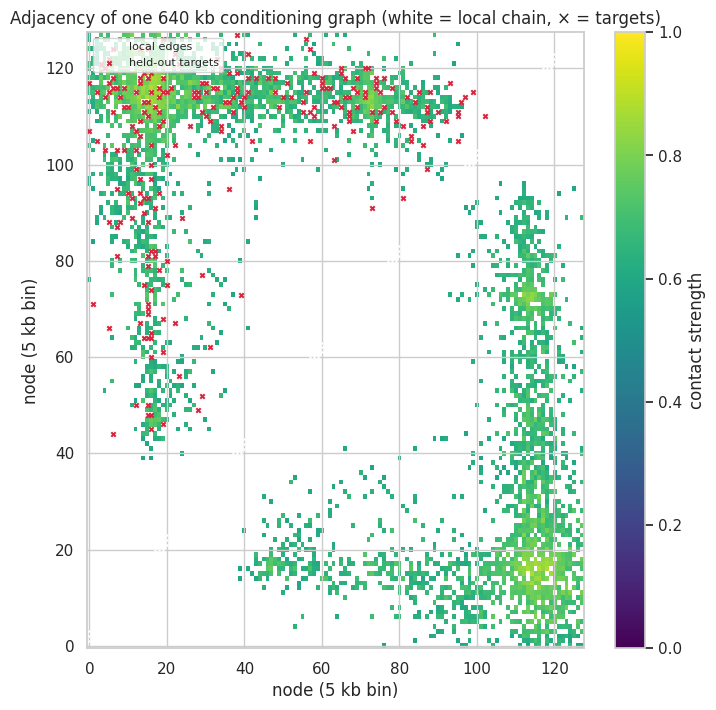

conditioning edges: 1797 (378 local + 1419 distal) | held-out targets: 231


In [23]:
# --- adjacency matrix of one sample's conditioning graph ---
local = smp.edge_is_local

adj_d = np.zeros((smp.n_nodes, smp.n_nodes))
adj_d[smp.edge_index[0, ~local], smp.edge_index[1, ~local]] = smp.edge_strength[~local]
adj_d += adj_d.T
adj_d = np.where(adj_d > 0, adj_d, np.nan)

fig, ax = plt.subplots(figsize=(8, 8))
im = ax.imshow(adj_d, cmap="viridis", origin="lower", vmin=0, vmax=1, aspect="auto")
ax.scatter(smp.edge_index[0, local], smp.edge_index[1, local],
           s=3, color="white", label="local edges", linewidths=0)
ax.scatter(smp.tgt_index[0], smp.tgt_index[1], s=10, marker="x",
           color="#d7263d", label="held-out targets")
plt.colorbar(im, ax=ax, label="contact strength")
ax.set_xlabel("node (5 kb bin)"); ax.set_ylabel("node (5 kb bin)")
ax.set_title("Adjacency of one 640 kb conditioning graph (white = local chain, × = targets)")
ax.legend(loc="upper left", fontsize=8)
plt.show()
print(f"conditioning edges: {smp.edge_index.shape[1]} ({int(local.sum())} local + "
      f"{int((~local).sum())} distal) | held-out targets: {smp.tgt_index.shape[1]}")

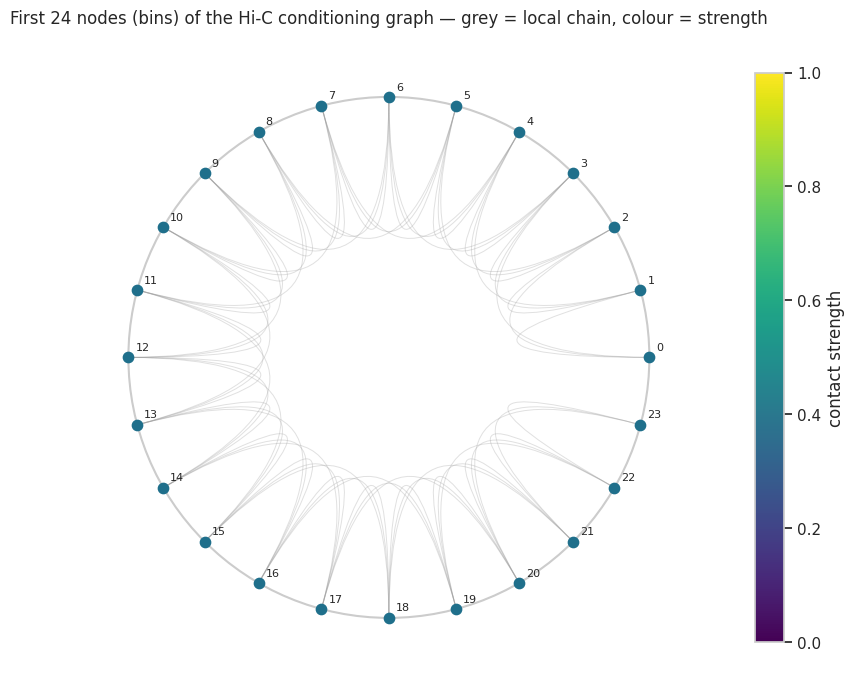

In [24]:
# --- circular chord graph: first 24 nodes ---
from matplotlib.path import Path as MPath
from matplotlib.patches import PathPatch
import matplotlib as mpl

n_show = 24
cks = np.linspace(0, 2 * np.pi, n_show, endpoint=False)
pts = np.c_[np.cos(cks), np.sin(cks)]

fig, ax = plt.subplots(figsize=(8.5, 8.5))
ax.add_patch(mpl.patches.Circle((0, 0), 1.0, fill=False, color="#cccccc", lw=1.5))
ax.scatter(pts[:, 0], pts[:, 1], s=55, color="#1f6f8b", zorder=5)
for i, (x, y) in enumerate(pts):
    ax.annotate(f"{i}", (x, y), textcoords="offset points", xytext=(5, 5), fontsize=8, zorder=6)

def chord(a, b, color, alpha, lw):
    (x0, y0), (x1, y1) = pts[a], pts[b]
    path = MPath([(x0, y0), (0.0, 0.0), (x1, y1)],
                 [MPath.MOVETO, MPath.CURVE3, MPath.CURVE3])
    ax.add_patch(PathPatch(path, fill=False, edgecolor=color, alpha=alpha, lw=lw,
                           zorder=2 if color == "0.6" else 3))

for ia, ib in smp.edge_index[:, local].T:
    if ia < n_show and ib < n_show:
        chord(ia, ib, "#9a9a9a", 0.30, 0.7)
d = ~local
top = np.argsort(-smp.edge_strength[d])[:70]
sm = plt.cm.ScalarMappable(cmap="viridis", norm=mpl.colors.Normalize(0, 1))
for s_, (ia, ib) in zip(smp.edge_strength[d][top], smp.edge_index[:, d][:, top].T):
    if ia < n_show and ib < n_show:
        chord(ia, ib, sm.to_rgba(s_), 0.85, 1.1 + 1.6 * s_)
plt.colorbar(sm, ax=ax, label="contact strength", shrink=0.7)
ax.set_xlim(-1.25, 1.25); ax.set_ylim(-1.25, 1.25)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("First 24 nodes (bins) of the Hi-C conditioning graph — grey = local chain, colour = strength")
plt.tight_layout(); plt.show()

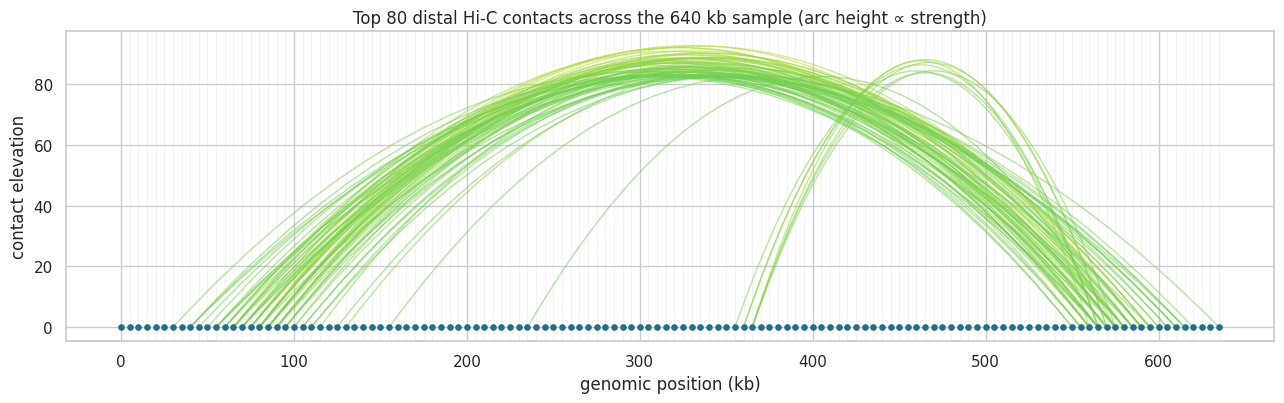

In [25]:
# --- arcs across genomic position: the strongest distal contacts ---
top = np.argsort(-smp.edge_strength[d])[:80]
pos = np.arange(smp.n_nodes) * cfg.data.bin_size / 1000          # kb
fig, ax = plt.subplots(figsize=(13, 4.2))
for k in range(smp.n_nodes):
    ax.axvline(pos[k], color="#e8e8e8", lw=0.4, zorder=0)
for s_, (ia, ib) in zip(smp.edge_strength[d][top], smp.edge_index[:, d][:, top].T):
    x1, x2 = pos[ia], pos[ib]
    h = 35 * s_ * min((x2 - x1) ** 0.4, 6.0)
    path = MPath([(x1, 0), ((x1 + x2) / 2, h), (x2, 0)],
                 [MPath.MOVETO, MPath.CURVE3, MPath.CURVE3])
    ax.add_patch(PathPatch(path, fill=False, edgecolor=(plt.cm.viridis(s_)),
                           alpha=0.55, lw=1.0))
ax.scatter(pos, np.zeros(smp.n_nodes), s=14, color="#1f6f8b", zorder=4)
ax.set_xlabel("genomic position (kb)"); ax.set_ylabel("contact elevation")
ax.set_title("Top 80 distal Hi-C contacts across the 640 kb sample (arc height ∝ strength)")
plt.tight_layout(); plt.show()

nodes              : 128
local degree       : constant 3..6 (expected 6 minus boundary effects)
distal degree      : mean 22.2, max 78 (each node selects top-16, and an edge survives if either endpoint picked it, so hubs can exceed it)
isolated (no distal): 0 nodes
edge density       : 0.2211 (fraction of all bin pairs that are edges)


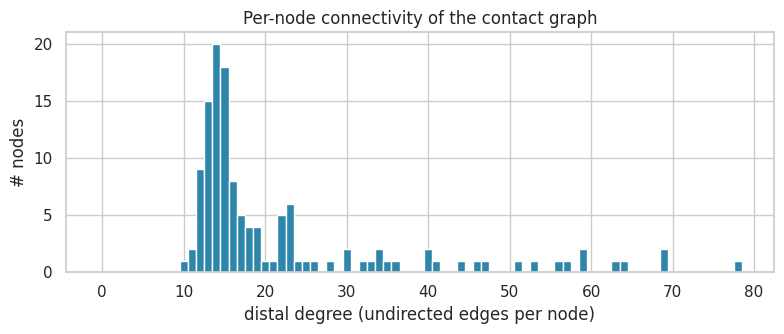

In [26]:
# --- degree & density of the conditioning graph ---
src, dst = smp.edge_index
deg_local = np.bincount(np.concatenate([src[local], dst[local]]), minlength=smp.n_nodes)
deg_distal = np.bincount(np.concatenate([src[d], dst[d]]), minlength=smp.n_nodes)

n_possible = smp.n_nodes * (smp.n_nodes - 1) / 2
print(f"nodes              : {smp.n_nodes}")
print(f"local degree       : constant {int(deg_local.min())}..{int(deg_local.max())} "
      f"(expected {2 * cfg.data.local_radius} minus boundary effects)")
print(f"distal degree      : mean {deg_distal.mean():.1f}, max {int(deg_distal.max())} "
      f"(each node selects top-{cfg.data.top_k_edges}, and an edge survives if "
      f"either endpoint picked it, so hubs can exceed it)")
print(f"isolated (no distal): {(deg_distal == 0).sum()} nodes")
print(f"edge density       : {smp.edge_index.shape[1] / n_possible:.4f} "
      f"(fraction of all bin pairs that are edges)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(deg_distal, bins=np.arange(-0.5, deg_distal.max() + 1.5), color="#2e86ab", edgecolor="white")
ax.set_xlabel("distal degree (undirected edges per node)"); ax.set_ylabel("# nodes")
ax.set_title("Per-node connectivity of the contact graph")
plt.tight_layout(); plt.show()

### 7.2 The seven experimental arms at the data level

Each arm corrupts the *same* graph the same way every time, so the only
difference between arms is the structural signal. Edge counts and target sizes
must be identical wherever possible (a control that changed count would confound
"wrong structure" with "less structure").

In [27]:
rep = json.loads((REPO / "data" / "graph_report_GM12878_chr20.json").read_text())
arms_df = pd.DataFrame([{k: r[k] for k in ("arm", "edges", "distal", "targets", "strength_mean", "sep_mean")} for r in rep])
arms_df

,arm,edges,distal,targets,strength_mean,sep_mean
0,b0_dna_only,378.000,0.000,219.5,NaN,NaN
1,b1_random_graph,1573.125,1195.125,219.5,0.614149,46.042752
2,b2_distance_only,1573.125,1195.125,219.5,0.500000,41.703865
3,b3_shuffled_hic,1573.125,1195.125,219.5,0.614646,41.703865
4,b4_late_fusion,378.000,0.000,219.5,NaN,NaN
5,b5_contrastive_only,378.000,0.000,219.5,NaN,NaN
6,full,1573.125,1195.125,219.5,0.614646,41.703865


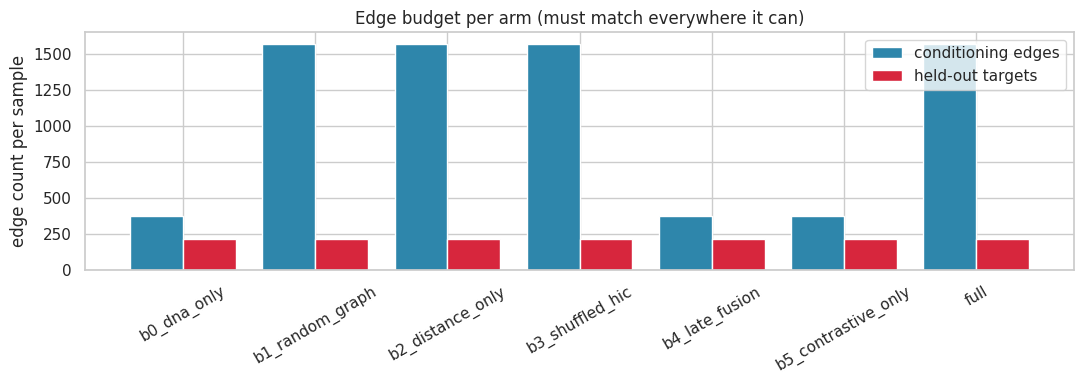

In [28]:
fig, ax = plt.subplots(figsize=(11, 4))
order = ["b0_dna_only", "b1_random_graph", "b2_distance_only", "b3_shuffled_hic",
         "b4_late_fusion", "b5_contrastive_only", "full"]
x = np.arange(len(order))
ax.bar(x - 0.2, arms_df.set_index("arm").loc[order, "edges"], 0.4, label="conditioning edges", color="#2e86ab")
ax.bar(x + 0.2, arms_df.set_index("arm").loc[order, "targets"], 0.4, label="held-out targets", color="#d7263d")
ax.set_xticks(x); ax.set_xticklabels(order, rotation=30)
ax.set_ylabel("edge count per sample"); ax.legend()
ax.set_title("Edge budget per arm (must match everywhere it can)")
plt.tight_layout(); plt.show()

## 8. Dataset scale: splits, samples, batch shapes

### 8.1 Chromosome-level splits

Hi-C is autocorrelated over megabases, so splits are chromosome-level, never
random windows.

In [29]:
sp = {"train": cfg.data.chroms_train, "val": cfg.data.chroms_val, "test": cfg.data.chroms_test}
split_df = pd.DataFrame([{"split": s, "chroms": ", ".join(c)} for s, c in sp.items()])
split_df

,split,chroms
0,train,"chr1, chr2, chr4, chr5, chr6, chr7, chr8, chr9..."
1,val,"chr10, chr11"
2,test,"chr3, chr13, chr17"


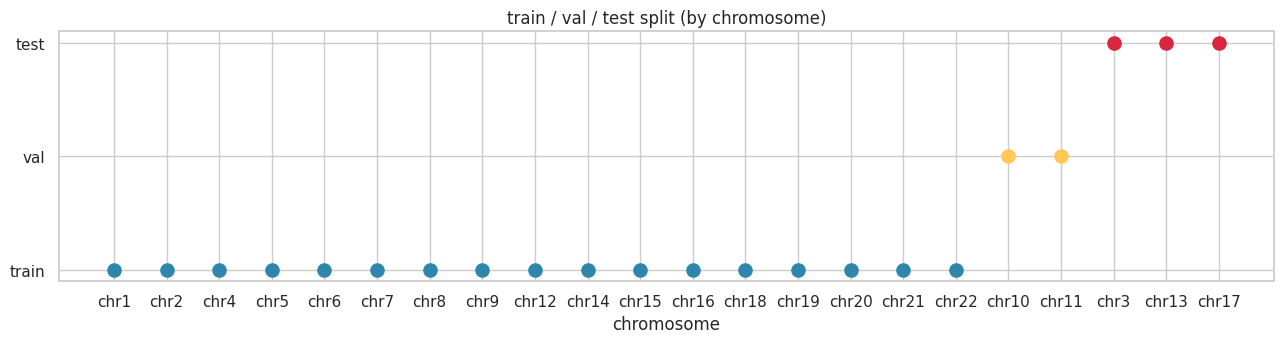

In [30]:
fig, ax = plt.subplots(figsize=(13, 3.6))
for s, c in _colors.items():
    if s == "unbuilt":
        continue
    chroms = sp[s]
    y = np.full(len(chroms), list(sp).index(s))
    ax.scatter(chroms, y, s=90, color=_colors[s], label=s)
ax.set_yticks(range(3)); ax.set_yticklabels(list(sp))
ax.set_xlabel("chromosome"); ax.set_title("train / val / test split (by chromosome)")
plt.tight_layout(); plt.show()

In [31]:
rows = []
for c in sp["train"]:
    ch_i = load_chromosome(data_dir(), "GM12878", c, cfg.data.bin_size)
    n_samples = len(sample_starts(len(ch_i["usable"]), cfg.data.nodes_per_sample, ch_i["usable"]))
    rows.append({"chrom": c, "usable_bins": int(ch_i["usable"].sum()),
                 "samples_per_epoch": n_samples})
train_scale = pd.DataFrame(rows)
print(f"total samples per epoch (train): {train_scale['samples_per_epoch'].sum()}")
print(f"context per sample: {cfg.data.context_bp/1000:.0f} kb")
train_scale

total samples per epoch (train): 6284
context per sample: 640 kb


,chrom,usable_bins,samples_per_epoch
0,chr1,44228,689
1,chr2,47056,734
2,chr4,37350,584
3,chr5,35004,547
4,chr6,33516,526
5,chr7,30595,478
6,chr8,28169,439
7,chr9,22332,342
8,chr12,25942,405
9,chr14,17374,272


### 8.2 One collated batch — the exact format training consumes

`chromgraph.train.collate` pads per-sample edge lists into fixed-width tensors
(edge counts are within a factor of ~2 because top-k caps them). This cell shows
the **shapes** only — no model is built or run.

In [32]:
from chromgraph.train import collate

ch_a = load_chromosome(data_dir(), "GM12878", "chr20", cfg.data.bin_size)
samples = [build_sample(cfg, ch_a, "GM12878", "chr20", s, arm="full")
           for s in (4000, 4064, 4128, 4192)]               # batch of 4 windows
batch = collate(samples)
for k, v in batch.items():
    if hasattr(v, "shape"):
        print(f"  {k:<16s} {str(tuple(v.shape)):>20s}  {str(v.dtype):>10s}")

  seq                    (4, 128, 5000)  torch.uint8
  node_ok                      (4, 128)  torch.bool
  node_hic_feat             (4, 128, 3)  torch.float32
  edge_index               (4, 2, 1797)  torch.int64
  edge_strength               (4, 1797)  torch.float32
  edge_sep                    (4, 1797)  torch.int64
  edge_mask                   (4, 1797)  torch.bool
  edge_is_local               (4, 1797)  torch.bool
  tgt_index                 (4, 2, 231)  torch.int64
  tgt_strength                 (4, 231)  torch.float32
  tgt_mask                     (4, 231)  torch.bool


## 9. Summary of the key numbers

| Quantity | Value | Why it matters |
|---|---|---|
| Resolution / context | 5 kb bins · 128 nodes = 640 kb | whole-sample context an attention network can afford |
| Genome | hg38, 3.1 GB, UCSC | assembly-gap N's flagged per bin |
| Hi-C | GM12878, 4DN, ICE-balanced, 5 kb | NaN = ICE-filtered bins (24 071 of 2.3 M in-band pixels) |
| Detrending | P(s) slope ≈ −0.91 / −0.88 / −0.93 (chr20/21/1); Spearman ≈ −0.03…−0.06 | distance effect removed before graphs are built |
| Usable bins | chr20 94%, chr21 73%, chr1 89% | below ~60% a window is not sampled |
| Edges / sample | ~1,573 conditioning, ~220 held-out targets (avg chr20/chr1) | top-16 distal per node + local chain |
| Train scale | **6,284 samples / epoch** across 17 train chromosomes | 640 kb windows at half-bin stride |

### Required caveats (from the manifest's own notes)

* **Sequencing depth.** GM12878's map comes from **72 experiments**; K562 has 6
  and IMR90 7. Any cross-cell-line comparison is partly a depth difference and
  must be disclosed as such.
* **Band cap.** `build_data.py` reads a near-diagonal band of **2 Mb**; beyond
  it the pixels never reach the model.
* **Reproducibility gate.** The `checksums` in every `qc.json` are the
  laptop-to-cluster gate — the rebuilt files must be byte-identical.

*This notebook never wrote to `data/`. All shards were opened read-only (mmap
for `seq.npy`).*